In [20]:
import nibabel as nib
import matplotlib.pyplot as plt
import numpy as np
import torch
from torchvision.transforms.functional import normalize

In [21]:
im_path = "/data/datasets/nii/MSD/Task07_Pancreas/imagesTs/pancreas_010.nii.gz"
gt_path = "/data/datasets/nii/MSD/Task07_Pancreas/labelsTs/pancreas_010.nii.gz"
im = nib.load(im_path).get_fdata()
gt = nib.load(gt_path).get_fdata()

In [22]:
scale = 1
im = torch.Tensor(im)
im = (im - im.min()) / (im.max() - im.min()) * scale
im = im.permute(2,0,1).unsqueeze(1).repeat(1,3,1,1)
im = normalize(
    im, 
    mean=[0.485 * scale, 0.456 * scale, 0.406 * scale],
    std=[0.229 * scale, 0.224 * scale, 0.225 * scale]
)
im = im * 255
# im = im.permute(0, 2, 3, 1)

In [23]:
im.min(), im.max()

(tensor(-540.0655), tensor(673.2000))

In [8]:
np.unique(gt)

array([0., 1., 2.])

In [9]:
gt[gt != 1] = 0
gt[gt == 1] = 1

In [10]:
np.argwhere(gt.sum(axis=(0, 1))).squeeze()

array([ 35,  36,  37,  38,  39,  40,  41,  42,  43,  44,  45,  46,  47,
        48,  49,  50,  51,  52,  53,  54,  55,  56,  57,  58,  59,  60,
        61,  62,  63,  64,  65,  66,  67,  68,  69,  70,  71,  72,  73,
        74,  75,  76,  77,  78,  79,  80,  81,  82,  83,  84,  85,  86,
        87,  88,  89,  90,  91,  92,  93,  94,  95,  96,  97,  98,  99,
       100, 101, 102, 103, 104, 105, 106, 107])

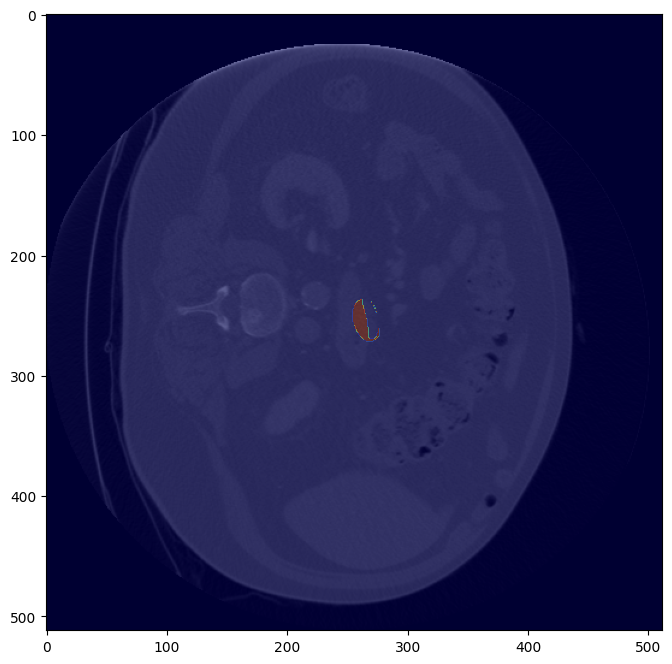

In [18]:
plt.figure(figsize=(8,8))
plt.imshow(im[36])
plt.imshow(gt[:, :, 36], alpha=0.4, cmap="jet")